# PhishGuard — Feature Engineering Analysis

Week 2 deliverable. Covers:
1. Feature extraction from the cleaned dataset
2. Hand-crafted feature distributions by class
3. Class separation analysis (mean difference per feature)
4. Feature correlation heatmap
5. Feature importance from Random Forest
6. False-positive / false-negative feature signatures

In [1]:
import sys
sys.path.insert(0, "..")
import warnings, logging
warnings.filterwarnings("ignore")
logging.basicConfig(level=logging.WARNING)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import joblib

plt.rcParams.update({
    "figure.dpi": 110,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 11,
})

from src.features.pipeline import build_feature_pipeline, get_feature_names

# Load cleaned data
df = pd.read_csv("../data/processed/cleaned.csv").fillna("")
y  = df["label"].values
print(f"Dataset: {df.shape[0]} rows, {y.mean()*100:.1f}% phishing")

Dataset: 5452 rows, 50.0% phishing


## 1. Feature Extraction

Fit the feature pipeline on the full dataset and extract the raw (pre-scaling) feature matrix for analysis.

In [2]:
pipe = build_feature_pipeline()
pipe.fit(df)

# Pre-scale features for interpretable analysis
X_raw = pipe.named_steps["features"].transform(df)
feature_names = np.array(get_feature_names(pipe))

feat_df = pd.DataFrame(X_raw, columns=feature_names)
feat_df["label"] = y

HAND_CRAFTED = feature_names[:30]   # manual features
SVD_FEATURES  = feature_names[30:]  # TF-IDF SVD components

print(f"Feature matrix shape : {X_raw.shape}")
print(f"Hand-crafted features: {len(HAND_CRAFTED)}")
print(f"  Text scalars  : {feature_names[:11].tolist()}")
print(f"  URL signals   : {feature_names[11:17].tolist()}")
print(f"  Structural    : {feature_names[17:25].tolist()}")
print(f"  Header        : {feature_names[25:30].tolist()}")
print(f"SVD components       : {len(SVD_FEATURES)}")

Feature matrix shape : (5452, 130)
Hand-crafted features: 30
  Text scalars  : ['urgency_score', 'caps_ratio', 'exclamation_count', 'question_count', 'punct_density', 'body_char_len', 'body_word_count', 'avg_word_len', 'unique_word_ratio', 'digit_ratio', 'flesch_reading_ease']
  URL signals   : ['url_count', 'display_mismatch_count', 'has_shortener', 'suspicious_tld_count', 'ip_url_count', 'max_url_entropy']
  Structural    : ['has_html', 'img_count', 'img_to_word_ratio', 'hidden_element_count', 'form_count', 'script_count', 'external_link_count', 'generic_salutation']
  Header        : ['has_reply_to', 'reply_to_differs', 'sender_is_freemail', 'display_name_mismatch', 'sender_domain_numeric']
SVD components       : 100


## 2. Hand-Crafted Feature Distributions by Class

Violin plots reveal how each manual feature separates ham (blue) from phishing (red).

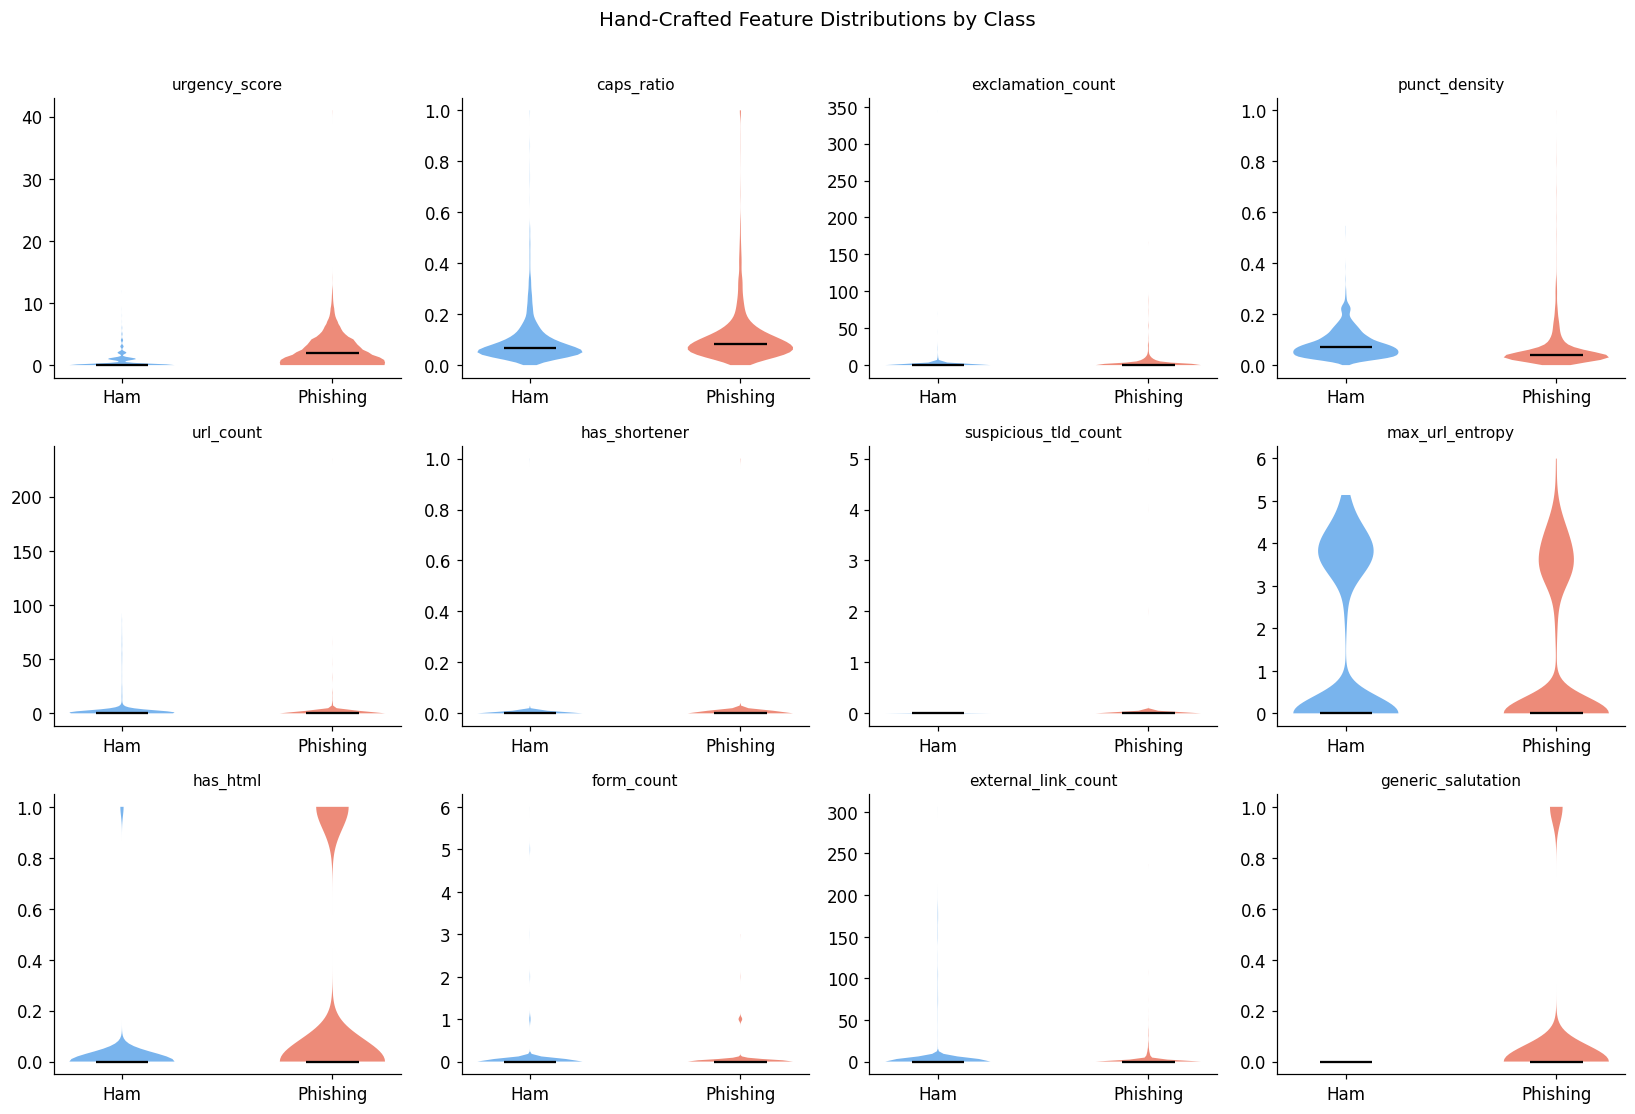

In [3]:
features_to_plot = [
    "urgency_score", "caps_ratio", "exclamation_count", "punct_density",
    "url_count", "has_shortener", "suspicious_tld_count", "max_url_entropy",
    "has_html", "form_count", "external_link_count", "generic_salutation",
]

COLORS = {0: "#4C9BE8", 1: "#E8644C"}
LABELS = {0: "Ham", 1: "Phishing"}

fig, axes = plt.subplots(3, 4, figsize=(15, 10))
axes = axes.flatten()

for ax, feat in zip(axes, features_to_plot):
    data  = [feat_df[feat_df["label"] == lbl][feat].values for lbl in [0, 1]]
    parts = ax.violinplot(data, positions=[0, 1], showmedians=True, showextrema=False)
    for i, body in enumerate(parts["bodies"]):
        body.set_facecolor(COLORS[i])
        body.set_alpha(0.75)
    parts["cmedians"].set_color("black")
    ax.set_xticks([0, 1])
    ax.set_xticklabels(["Ham", "Phishing"])
    ax.set_title(feat, fontsize=10)

plt.suptitle("Hand-Crafted Feature Distributions by Class", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## 3. Class Separation Analysis

For each hand-crafted feature: mean per class, difference, and Cohen's d — a standardised effect size. Larger |d| = better single-feature discriminator.

               feature  ham_mean  phish_mean      diff  cohens_d
         urgency_score    0.5018      2.2161    1.7142    0.9557
     unique_word_ratio    0.7508      0.6375   -0.1134   -0.6419
              has_html    0.0301      0.2359    0.2058    0.6359
    generic_salutation    0.0000      0.1071    0.1071    0.4897
    sender_is_freemail    0.0257      0.1453    0.1196    0.4378
 display_name_mismatch    0.0004      0.0609    0.0605    0.3567
   flesch_reading_ease   59.2614     52.8873   -6.3741   -0.3151
         punct_density    0.0819      0.0614   -0.0204   -0.3089
          ip_url_count    0.0084      0.3569    0.3485    0.2770
     exclamation_count    0.8364      2.8760    2.0396    0.2542
           digit_ratio    0.0389      0.0264   -0.0124   -0.2391
 sender_domain_numeric    0.0139      0.0580    0.0440    0.2381
            caps_ratio    0.0906      0.1093    0.0188    0.1923
       max_url_entropy    1.7424      1.4020   -0.3404   -0.1793
             url_count   

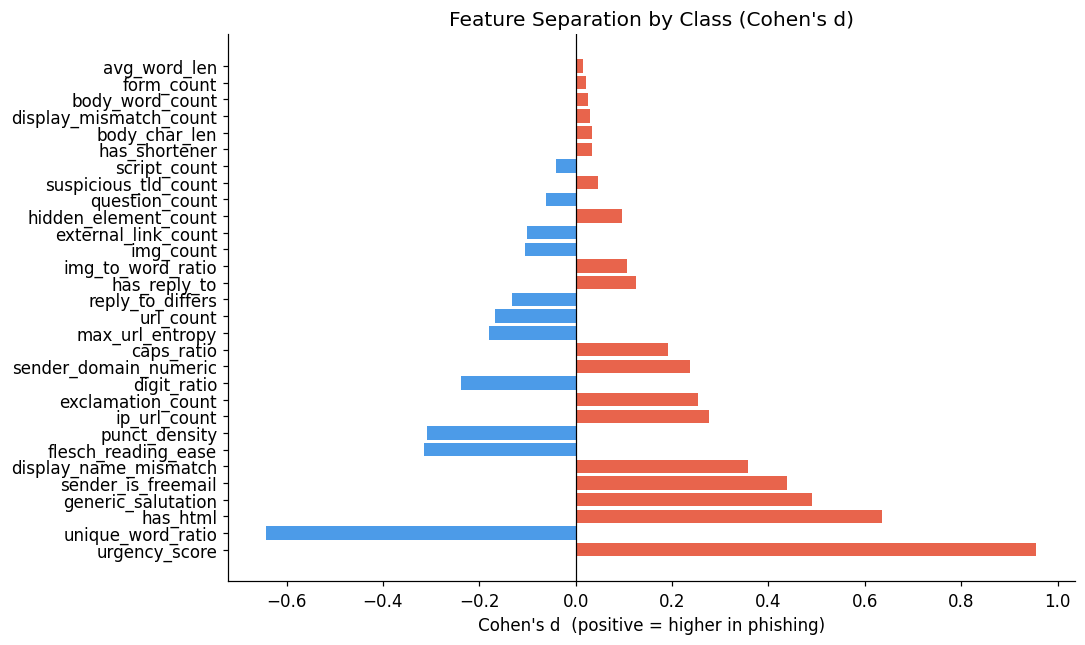

In [4]:
ham   = feat_df[feat_df["label"] == 0]
phish = feat_df[feat_df["label"] == 1]

rows = []
for f in HAND_CRAFTED:
    h_mean, p_mean = ham[f].mean(), phish[f].mean()
    pooled_std = np.sqrt((ham[f].std()**2 + phish[f].std()**2) / 2)
    cohens_d   = (p_mean - h_mean) / pooled_std if pooled_std > 0 else 0.0
    rows.append({"feature": f, "ham_mean": h_mean, "phish_mean": p_mean,
                 "diff": p_mean - h_mean, "cohens_d": cohens_d})

sep = pd.DataFrame(rows).sort_values("cohens_d", key=abs, ascending=False)
print(sep.to_string(index=False, float_format="{:.4f}".format))

fig, ax = plt.subplots(figsize=(10, 6))
colors = ["#E8644C" if d > 0 else "#4C9BE8" for d in sep["cohens_d"]]
ax.barh(sep["feature"], sep["cohens_d"], color=colors)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Cohen's d  (positive = higher in phishing)")
ax.set_title("Feature Separation by Class (Cohen's d)")
plt.tight_layout()
plt.show()

## 4. Feature Correlation Heatmap

Correlations among hand-crafted features. Highly correlated pairs are redundant — good to know before Week 3 feature selection.

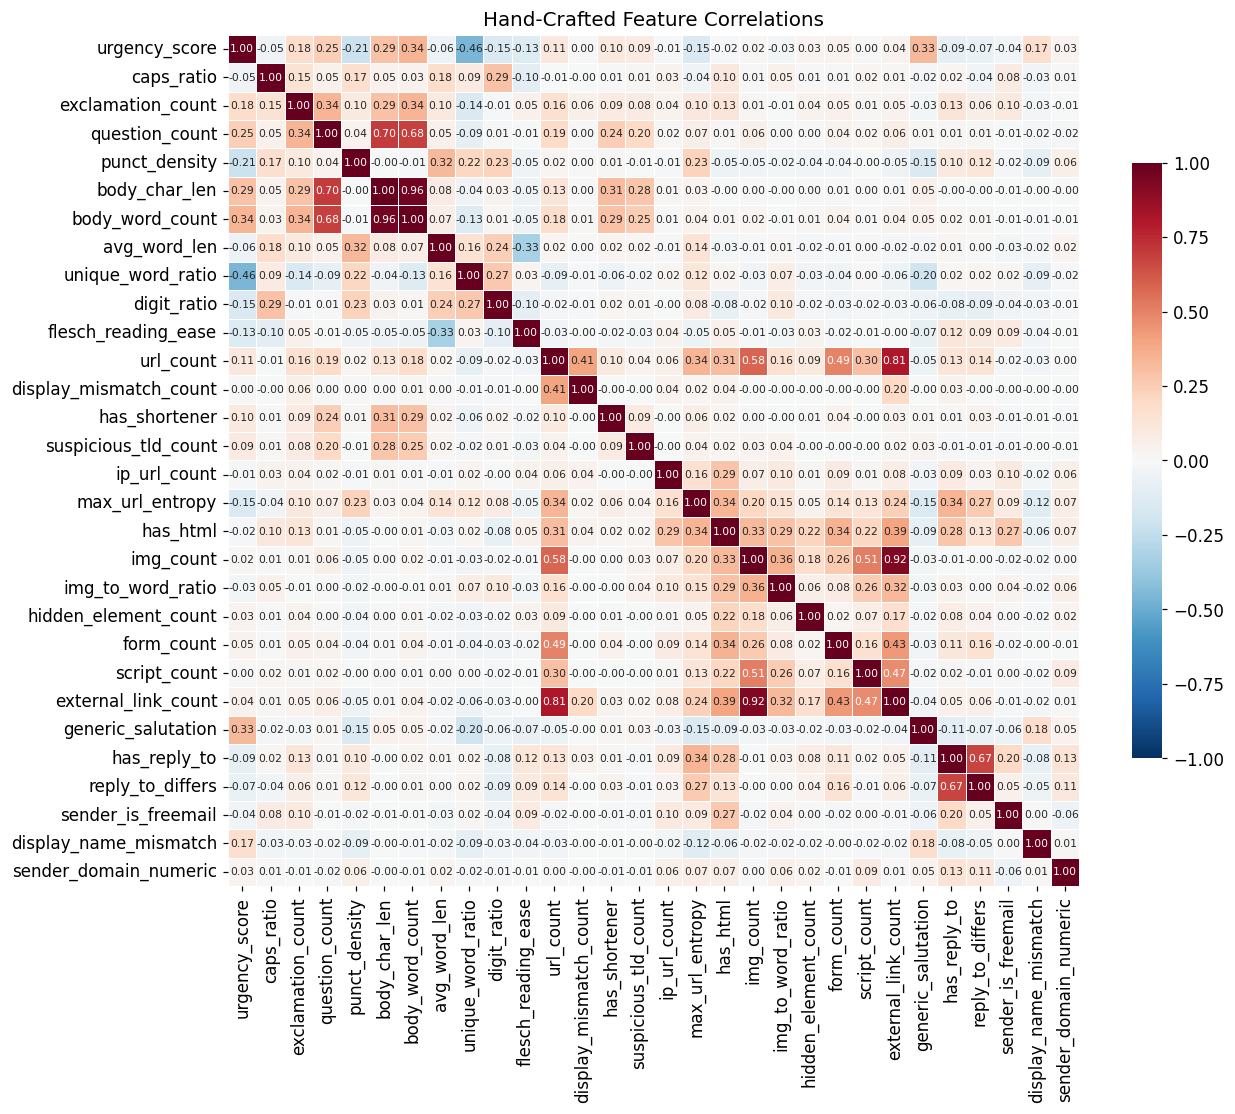

In [5]:
corr = feat_df[list(HAND_CRAFTED)].corr()

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(
    corr, ax=ax,
    cmap="RdBu_r", center=0, vmin=-1, vmax=1,
    annot=True, fmt=".2f", annot_kws={"size": 7},
    linewidths=0.4, square=True,
    cbar_kws={"shrink": 0.7},
)
ax.set_title("Hand-Crafted Feature Correlations", fontsize=13)
plt.tight_layout()
plt.show()

## 5. Feature Importance (Random Forest)

Random Forest permutation-style impurity importance across all 130 features. Top 25 shown.

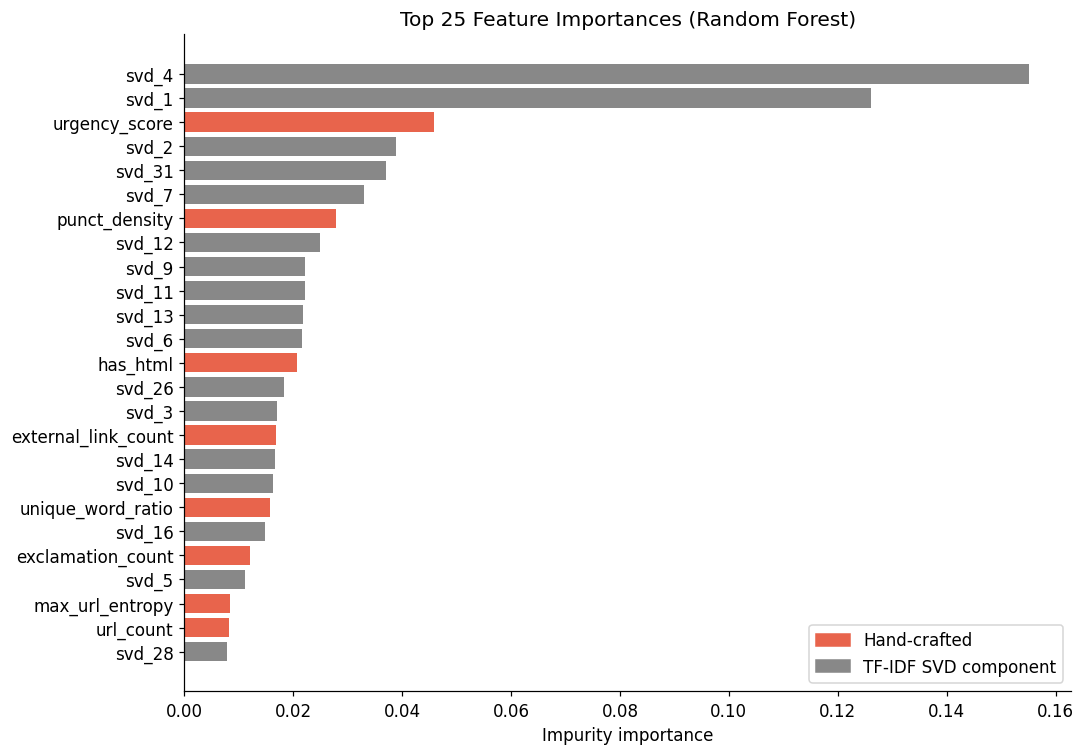

In [6]:
from pathlib import Path

artifact = joblib.load("../models/artifacts/random_forest.joblib")
rf_model = artifact["model"]

importances = rf_model.feature_importances_
idx = np.argsort(importances)[::-1][:25]

fig, ax = plt.subplots(figsize=(10, 7))
colors = ["#E8644C" if f in HAND_CRAFTED else "#888" for f in feature_names[idx]]
ax.barh(
    [feature_names[i] for i in idx][::-1],
    importances[idx][::-1],
    color=colors[::-1],
)
ax.set_xlabel("Impurity importance")
ax.set_title("Top 25 Feature Importances (Random Forest)")

from matplotlib.patches import Patch
legend = [
    Patch(color="#E8644C", label="Hand-crafted"),
    Patch(color="#888",    label="TF-IDF SVD component"),
]
ax.legend(handles=legend, loc="lower right")
plt.tight_layout()
plt.show()

## 6. Feature Signatures: False Negatives vs. True Positives

Compare the hand-crafted feature profiles of emails the Random Forest *missed* (false negatives) against those it caught correctly. This reveals what makes certain phishing emails harder to detect.

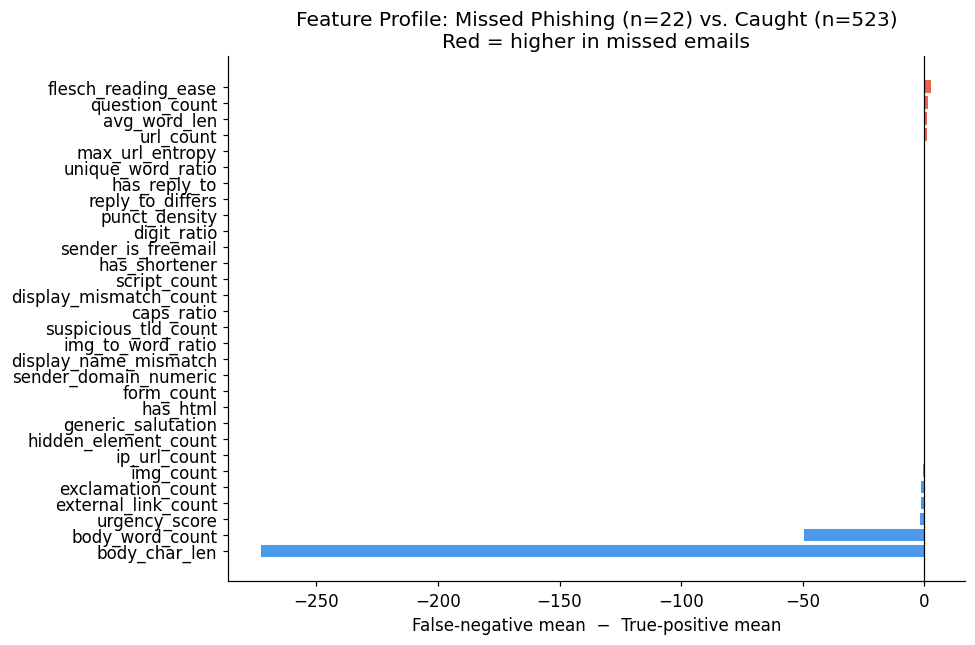


False negatives : 22
True positives  : 523


In [7]:
from sklearn.model_selection import train_test_split

X_df   = df.drop(columns=["label", "source"], errors="ignore")
_, X_test_df, _, y_test = train_test_split(
    X_df, y, test_size=0.2, random_state=42, stratify=y
)

fp_pipe   = artifact["feature_pipeline"]
threshold = artifact["threshold"]

X_test_feat = fp_pipe.transform(X_test_df)
y_proba     = rf_model.predict_proba(X_test_feat)[:, 1]
y_pred      = (y_proba >= threshold).astype(int)

phish_mask = y_test == 1
fn_mask    = phish_mask & (y_pred == 0)   # false negatives
tp_mask    = phish_mask & (y_pred == 1)   # true positives

# Raw (pre-scale) features for the test subset
test_raw   = fp_pipe.named_steps["features"].transform(X_test_df)
test_feats = pd.DataFrame(test_raw, columns=feature_names)

fn_means = test_feats[fn_mask][list(HAND_CRAFTED)].mean()
tp_means = test_feats[tp_mask][list(HAND_CRAFTED)].mean()

diff = (fn_means - tp_means).sort_values()

fig, ax = plt.subplots(figsize=(9, 6))
colors = ["#E8644C" if v > 0 else "#4C9BE8" for v in diff]
ax.barh(diff.index, diff.values, color=colors)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("False-negative mean  −  True-positive mean")
ax.set_title(
    f"Feature Profile: Missed Phishing (n={fn_mask.sum()}) vs. Caught (n={tp_mask.sum()})\n"
    "Red = higher in missed emails"
)
plt.tight_layout()
plt.show()

print(f"\nFalse negatives : {fn_mask.sum()}")
print(f"True positives  : {tp_mask.sum()}")